## 僅在路上的區域做偵測

In [1]:
# 劃出要做偵測的區域
#  Obtained with Roboflow
Road_points = {"points": [[[0, 128.125], [586.875, 48.125], [626.25, 53.75], [515.625, 359], [1.25, 359]]]}
Danger_points =  {"points": [[[0, 180.125], [180, 150], [380, 120], [586.875, 48.125], [626.25, 53.75], [515.625, 359], [1.25, 359]]]}

In [2]:
# 透過自定義模組 AreaEntity 來做包裝
from utlis.RoadEntity import AreaEntity

if len(Road_points["points"]) == 1:
    Road_area = AreaEntity(Road_points["points"])

if len(Danger_points["points"]) == 1:
    Danger_area = AreaEntity(Danger_points["points"])

In [3]:
import cv2
from ultralytics import YOLO
from collections import defaultdict

# 載入 YOLO 模型
model = YOLO('yolov8n.pt')

# 模型所偵測的類別列表
class_list = model.names 
# {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane',\
#  5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light',...}

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 開啟影片檔案
video_path = 'Pedestrian_on_roads_1.mp4'
cap = cv2.VideoCapture(video_path)
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))
fps = int(cap.get(cv2.CAP_PROP_FPS))
ret, frame = cap.read()

### 畫出要偵測區域範圍 （cropped_frame）

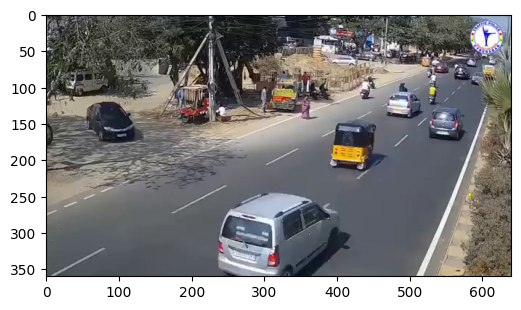

In [5]:
# cv2.imwrite("Pedestrian_on_roads_screenshot.jpg", frame)

from PIL import Image
import matplotlib.pyplot as plt

# Load the image
img = Image.open("Pedestrian_on_roads_screenshot.jpg")

# 用 Matplotlib 顯示影像
plt.figure(figsize=(6,6))
plt.imshow(img)
# plt.axis("off")  # 隱藏座標軸
plt.show()

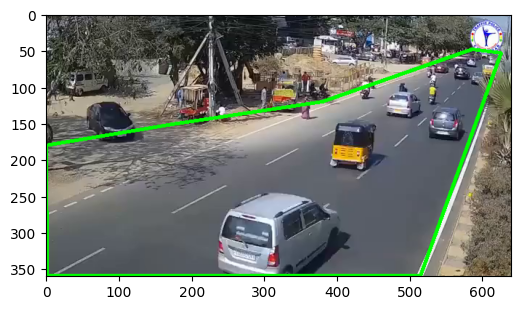

In [6]:
# 繪製多邊形
cv2.polylines(frame, [Danger_area.contour], isClosed=True, color=(0, 255, 0), thickness=3)

# 轉換 BGR 到 RGB (因為 matplotlib 使用 RGB)
img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# 用 Matplotlib 顯示影像
plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
# plt.axis("off")  # 隱藏座標軸
plt.show()

#### `cropped_frame` obtained by mask

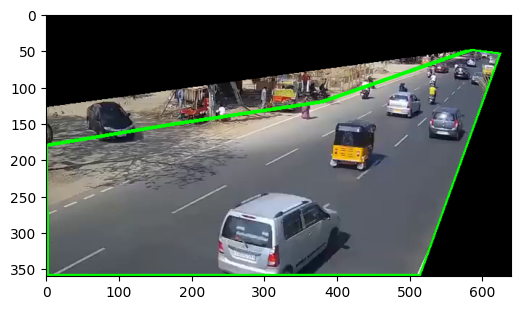

In [7]:
cv2.polylines(frame, [Danger_area.contour], isClosed=True, color=(0, 255, 0), thickness=3)


mask = np.zeros_like(frame)

# Fill the polygon area with white (255) in the mask
cv2.fillPoly(mask, [Road_area.contour], (255, 255, 255))

# Apply the mask to the original frame using bitwise_and
cropped_frame = cv2.bitwise_and(frame, mask)
cropped_rgb = cv2.cvtColor(cropped_frame, cv2.COLOR_BGR2RGB)


plt.figure(figsize=(6,6))
plt.imshow(cropped_rgb)
# plt.axis("off")  # 隱藏座標軸
plt.show()

##### `cropping frame` as a function
用在影片的每幀影像

In [8]:
import numpy as np

def cropping_frame(frame):
    mask = np.zeros_like(frame)

    # Fill the polygon area with white (255) in the mask
    cv2.fillPoly(mask, [Road_area.contour], (255, 255, 255))

    # Apply the mask to the original frame using bitwise_and
    cropped_frame = cv2.bitwise_and(frame, mask)

    return cropped_frame

In [9]:
def frame_data(frame_count, detect_result):
    # type of `detect_result`: ultralytics.engine.results.Results #
    #-----------------------------------------------------------#

    predictions = detect_result.boxes.data.cpu().numpy()

    # 構建一個列表來存儲每個物件的結果
    f_data = []
    # 遍歷每個預測框並提取資料
    for pred_idx in range(len(predictions)):
        # 假設每個 pred 物件有 name, class, confidence 和 box 屬性
        class_idx = int(predictions[pred_idx][-1])
        f_data.append({
            "frame_number": frame_count,
            "class_name": detect_result.names[class_idx],  # 類別名稱
            "class_id": class_idx,  # 類別ID
            "instance_id": int(detect_result.boxes.id[pred_idx].cpu().numpy()),
            "confidence": float(predictions[pred_idx][-2]),  # 預測置信度
            "box": {
                "x1": float(predictions[pred_idx][0]),  # 預測框的左上角 x
                "y1": float(predictions[pred_idx][1]),  # 預測框的左上角 y
                "x2": float(predictions[pred_idx][2]),  # 預測框的右下角 x
                "y2": float(predictions[pred_idx][3])   # 預測框的右下角 y
            }
        })


    return f_data

In [ ]:
# dictionary for 儲存每個 class 出現的物件數目
class_counts = defaultdict(int)
detect_video_output = "Pedestrian_on_roads_1_detect_in_cropped_area.mp4"
out = cv2.VideoWriter(detect_video_output, cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))

frame_count = 0
output_data = []

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    cropped_frame = cropping_frame(frame)

    # 對限制的區域作 YOLO tracking
    results = model.track(cropped_frame, persist=True, imgsz=1280, show=False, classes = [0, 1,2,3,5,7]) 

    # 確保偵測結果不是 `empty`
    if results[0].boxes.data is not None:
        output_data.extend(frame_data(frame_count,results[0]))

        try:
        # Get the detected boxes, their class indices, and track IDs

            boxes = results[0].boxes.xyxy.cpu()
            track_ids = results[0].boxes.id.int().cpu().tolist()
            class_indices = results[0].boxes.cls.int().cpu().tolist()
            confidences = results[0].boxes.conf.cpu()

        except:
            print(results[0].boxes.data)

        # 針對每個被偵測到的物件
        for box, track_id, class_idx, conf in zip(boxes, track_ids, class_indices, confidences):
            x1, y1, x2, y2 = map(int, box)
            cx = (x1 + x2) // 2
            cy = (y1 + y2) // 2

            # cx, cy 作為物件中心點

            class_name = class_list[class_idx]
            label_color = (0, 255, 0)

            result = cv2.pointPolygonTest(Danger_area.contour, (x2, y1), measureDist=False)

            if result >= 0:

                if class_idx == 0:
                    label_color = (0, 0, 255)
                elif class_idx == 1 or class_idx == 3:
                    label_color = (255, 0, 0)

                cv2.circle(frame, (cx, cy), 4, label_color, -1)
                
                cv2.putText(frame, f"ID: {track_id} {class_name}", (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, label_color, 2)
                cv2.rectangle(frame, (x1, y1), (x2, y2), label_color, 2) 

    
    
    # # Show the frame
    frame_resized = cv2.resize(frame, (1280, 720))

    cv2.imshow("YOLO Object Tracking & Counting", frame_resized)
    cv2.resizeWindow("YOLO Object Tracking & Counting", 1280, 720)
    out.write(frame)
    
    
    # Exit loop if 'q' key is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
out.release()
cv2.destroyAllWindows()


0: 736x1280 7 persons, 11 cars, 2 motorcycles, 2 buss, 3 trucks, 273.9ms
Speed: 7.8ms preprocess, 273.9ms inference, 2.0ms postprocess per image at shape (1, 3, 736, 1280)

0: 736x1280 6 persons, 12 cars, 2 motorcycles, 2 buss, 2 trucks, 243.0ms
Speed: 7.0ms preprocess, 243.0ms inference, 2.3ms postprocess per image at shape (1, 3, 736, 1280)

0: 736x1280 6 persons, 11 cars, 1 bus, 3 trucks, 227.2ms
Speed: 5.9ms preprocess, 227.2ms inference, 3.0ms postprocess per image at shape (1, 3, 736, 1280)

0: 736x1280 6 persons, 11 cars, 1 motorcycle, 1 bus, 2 trucks, 211.5ms
Speed: 8.1ms preprocess, 211.5ms inference, 3.5ms postprocess per image at shape (1, 3, 736, 1280)

0: 736x1280 6 persons, 10 cars, 1 bus, 3 trucks, 219.3ms
Speed: 8.5ms preprocess, 219.3ms inference, 3.1ms postprocess per image at shape (1, 3, 736, 1280)

0: 736x1280 6 persons, 11 cars, 2 buss, 2 trucks, 207.4ms
Speed: 7.0ms preprocess, 207.4ms inference, 3.5ms postprocess per image at shape (1, 3, 736, 1280)

0: 736x128

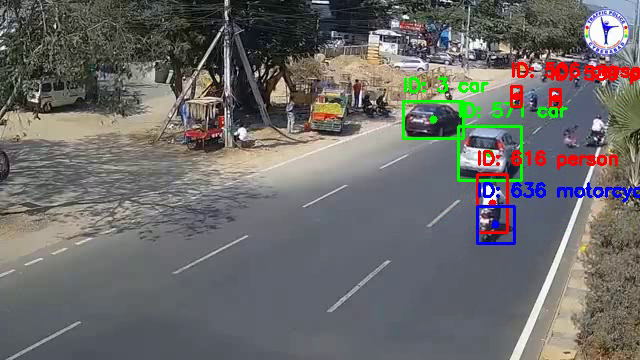

In [11]:
import cv2
import IPython.display as display
from PIL import Image

cap = cv2.VideoCapture("Pedestrian_on_roads_1_detect_in_cropped_area.mp4")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # OpenCV 預設是 BGR，轉換為 RGB
    img = Image.fromarray(frame)
    
    display.clear_output(wait=True)
    display.display(img)  # 顯示當前幀
    
cap.release()

In [13]:
import json

# 儲存為正確的 JSON 格式
with open('video_detect_output_example.json', 'w') as json_file:
    json.dump(output_data, json_file, indent=4)
